NGC6791 J19213390+3750202 (Calibration star):   
Temperature: 3956 K     
Surface Gravity: 1.0    
Overall Metallicity: 0.18   
α elements: 0.17    

NE1-1 001:  
Temperature: 3029 K     
Surface Gravity: 1.0    
Overall Metallicity: 0.14   
α elements: -0.01   

NE1-1 002:  
Temperature: 3294 K     
Surface Gravity: 1.0    
Overall Metallicity: >0.6   
α elements: -0.01   

In [1]:
%load_ext autoreload
%autoreload 2
import warnings

warnings.filterwarnings("ignore")
import ipywidgets as widgets
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.ndimage as nd
from astropy import units as u
from astropy.stats import sigma_clip

from src.funcs import (
    bass_compare,
    continuum_visualizer,
    convert_wavelength_air2vacuum,
    show_plots,
)
from stardis.base import run_stardis

Iterations:          0/? [00:00<?, ?it/s]

Packets:             0/? [00:00<?, ?it/s]

In [2]:
obs_w_lambda = 1 * u.Angstrom
obs_df = pd.read_csv("../data/getSolarSpectrumDB.dat", skipinitialspace=True)
obs_wave = convert_wavelength_air2vacuum(obs_df.iloc[:, 0])
obs_flux = obs_df.iloc[:, 1]

In [4]:
sim_delta_lambda = 0.01 * u.Angstrom

tracing_wavelengths = np.mgrid[6061 : 7061 : sim_delta_lambda.value] * u.Angstrom
sim_full = run_stardis("calibration.yml", tracing_wavelengths)
sim_nolines = run_stardis("calibration_nolines.yml", tracing_wavelengths)

sim_normalized_flux = sim_full.spectrum_lambda / sim_nolines.spectrum_lambda * 9920

obs_sigma_lambda = obs_w_lambda / 2.355
obs_sigma_pix = obs_sigma_lambda / sim_delta_lambda
sim_convolved_flux = nd.gaussian_filter1d(sim_normalized_flux, obs_sigma_pix)

Negative ionic molecules not currently supported. Assuming no H2-.
Negative ionic molecules not currently supported. Assuming no C2-.
Negative ionic molecules not currently supported. Assuming no CH-.
Negative ionic molecules not currently supported. Assuming no OH-.
Negative ionic molecules not currently supported. Assuming no SiH-.
Negative ionic molecules not currently supported. Assuming no HS-.
Negative ionic molecules not currently supported. Assuming no CN-.
Negative ionic molecules not currently supported. Assuming no CS-.
Negative ionic molecules not currently supported. Assuming no FeO-.
Negative ionic molecules not currently supported. Assuming no H2-.
Negative ionic molecules not currently supported. Assuming no C2-.
Negative ionic molecules not currently supported. Assuming no CH-.
Negative ionic molecules not currently supported. Assuming no OH-.
Negative ionic molecules not currently supported. Assuming no SiH-.
Negative ionic molecules not currently supported. Assuming 

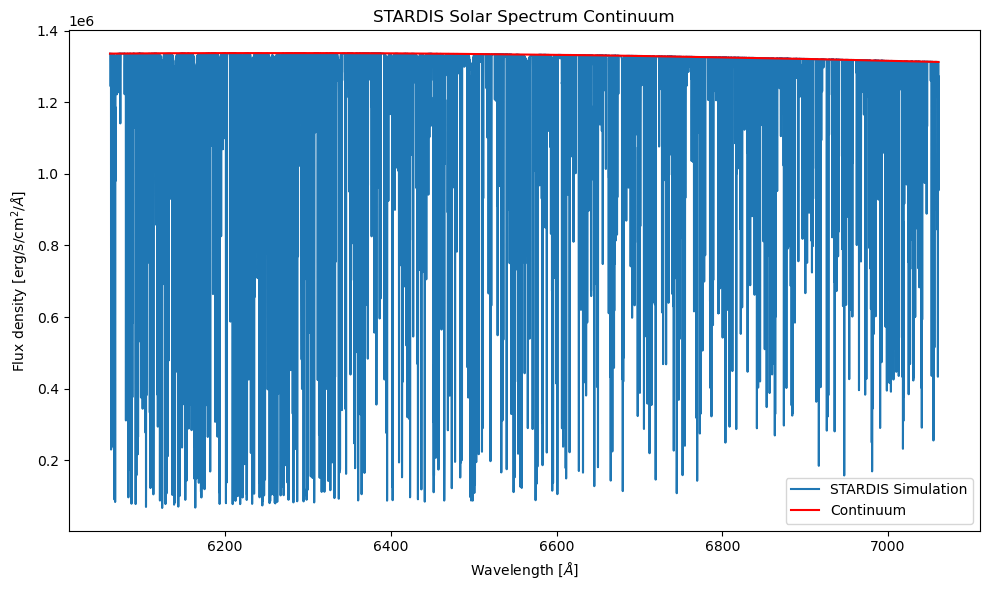

In [5]:
continuum_visualizer(sim_full.lambdas, sim_full.spectrum_lambda, sim_nolines.lambdas, sim_nolines.spectrum_lambda)

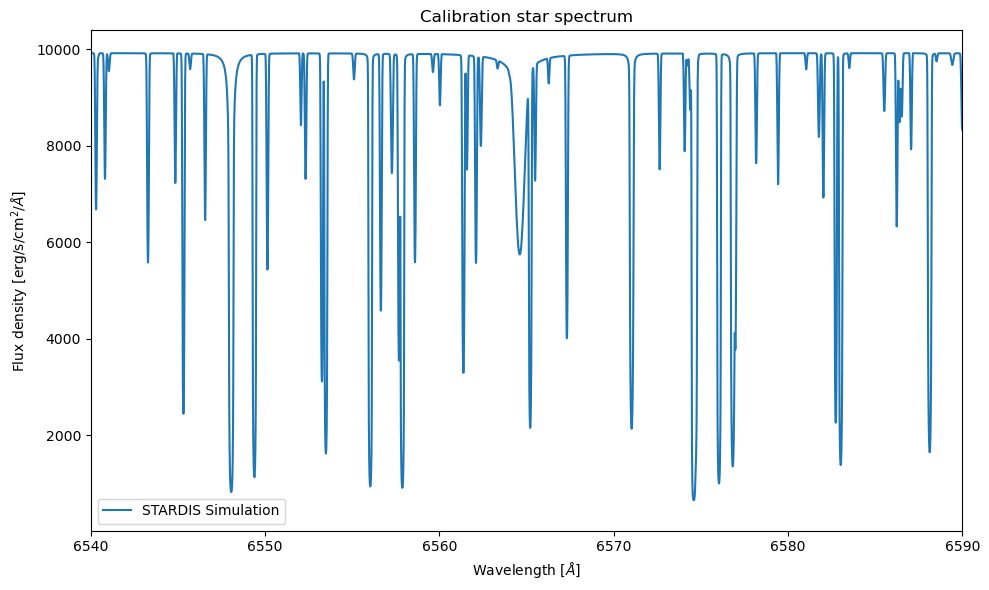

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(
    sim_full.lambdas,
    sim_normalized_flux,
    label="STARDIS Simulation",
    color="tab:blue",
)
plt.xlim(6540, 6590)
plt.title("Calibration star spectrum")
plt.xlabel(r"Wavelength [$\AA$]")
plt.ylabel(r"Flux density [erg/s/cm$^2$/$\AA$]")
plt.tight_layout()
plt.legend()
plt.show()